In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
clean_df = pd.read_csv('clean_resume_data.csv')

In [4]:
clean_df.head()

,ID,Category,Feature
0,16852973,HR,hr administrator marketing associate hr admini...
1,22323967,HR,hr specialist hr operations summary media prof...
2,33176873,HR,hr director summary years experience recruitin...
3,27018550,HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR,hr manager skill highlights hr skills hr depar...


In [5]:
clean_df.shape

(2484, 3)

# Exploratory Data Analysis

In [6]:
clean_df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

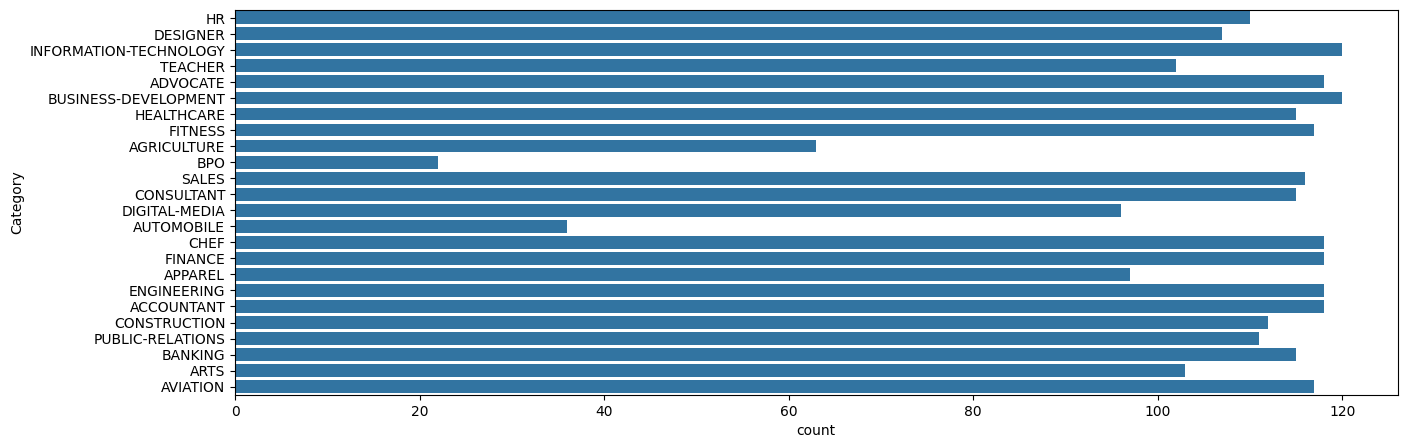

In [7]:
plt.figure(figsize=(15,5))
sns.countplot(clean_df['Category'])
plt.show()

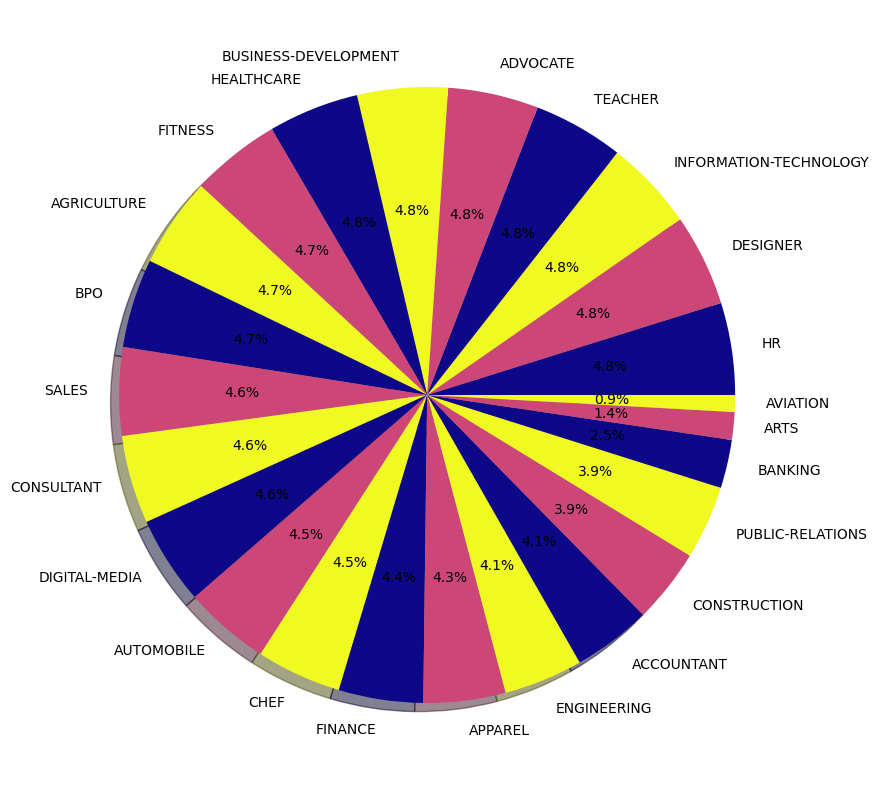

In [8]:
counts = clean_df ['Category'].value_counts()
labels = clean_df['Category'].unique()
plt.figure(figsize=(15,10))

plt.pie(counts, labels=labels, autopct='%1.1f%%', shadow=True, colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

In [9]:
clean_df['Category'].unique()

<StringArray>
[                    'HR',               'DESIGNER', 'INFORMATION-TECHNOLOGY',
                'TEACHER',               'ADVOCATE',   'BUSINESS-DEVELOPMENT',
             'HEALTHCARE',                'FITNESS',            'AGRICULTURE',
                    'BPO',                  'SALES',             'CONSULTANT',
          'DIGITAL-MEDIA',             'AUTOMOBILE',                   'CHEF',
                'FINANCE',                'APPAREL',            'ENGINEERING',
             'ACCOUNTANT',           'CONSTRUCTION',       'PUBLIC-RELATIONS',
                'BANKING',                   'ARTS',               'AVIATION']
Length: 24, dtype: str

# Balance Data

In [10]:
from sklearn.utils import resample

# Define the maximum count among all categories
max_count = clean_df ['Category'].value_counts().max()

# Resample each category to match the maximum count
balanced_data = []
for category in clean_df['Category'].unique():
    category_data = clean_df[clean_df['Category'] == category]
    
    if len(category_data) < max_count:
        #Perform oversampling for categories with fewer samples
        balanced_category_data = resample (category_data, replace=True, n_samples=max_count, random_state=42)

    else:
        #Perform undersampling for categories with more samples
        balanced_category_data = resample (category_data, replace=False, n_samples=max_count, random_state=42)
    balanced_data.append(balanced_category_data)

#Concatenate the balanced data for all categories
balanced_df = pd.concat(balanced_data)

In [11]:
balanced_df['Category'].value_counts()

Category
HR                        120
DESIGNER                  120
INFORMATION-TECHNOLOGY    120
TEACHER                   120
ADVOCATE                  120
BUSINESS-DEVELOPMENT      120
HEALTHCARE                120
FITNESS                   120
AGRICULTURE               120
BPO                       120
SALES                     120
CONSULTANT                120
DIGITAL-MEDIA             120
AUTOMOBILE                120
CHEF                      120
FINANCE                   120
APPAREL                   120
ENGINEERING               120
ACCOUNTANT                120
CONSTRUCTION              120
PUBLIC-RELATIONS          120
BANKING                   120
ARTS                      120
AVIATION                  120
Name: count, dtype: int64

In [12]:
balanced_df.dropna(inplace=True)

# Train-Test Split

In [13]:
X = balanced_df['Feature']
y = balanced_df ['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encoding (TF - IDF)

In [14]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 179711 stored elements and shape (576, 29780)>

# Train Random Forest Classifier

In [15]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train_tfidf, y_train)

y_pred = rf_classifier.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8298611111111112


In [16]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.87      0.95      0.91        21
              ADVOCATE       1.00      0.66      0.79        29
           AGRICULTURE       0.95      0.83      0.88        23
               APPAREL       0.85      0.81      0.83        21
                  ARTS       0.93      0.64      0.76        22
            AUTOMOBILE       1.00      1.00      1.00        19
              AVIATION       0.88      1.00      0.94        30
               BANKING       0.95      0.78      0.86        23
                   BPO       1.00      1.00      1.00        15
  BUSINESS-DEVELOPMENT       0.43      0.56      0.49        18
                  CHEF       0.93      0.96      0.95        28
          CONSTRUCTION       0.92      0.96      0.94        25
            CONSULTANT       0.90      0.61      0.73        31
              DESIGNER       0.88      0.79      0.83        28
         DIGITAL-MEDIA       0.77      

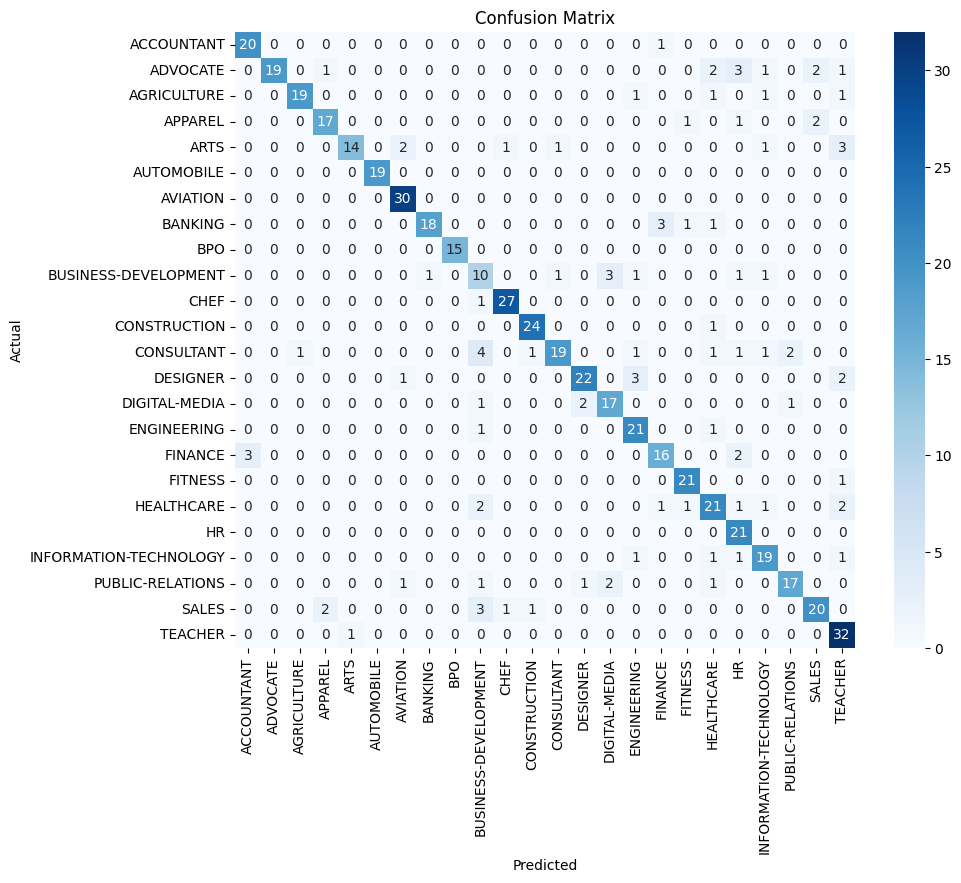

In [17]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_classifier.classes_,
    yticklabels=rf_classifier.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



# Predictive System

In [18]:
#Clean resume

import re
import string

def cleanResume(txt):
    cleanText = re.sub(r'http\S+\s', ' ', txt)
    cleanText = re.sub(r'RT cc', ' ', cleanText)
    cleanText = re.sub(r'#\S+\s', ' ', cleanText)
    cleanText = re.sub(r'@\S+', ' ', cleanText)
    cleanText = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub(r'\s+', ' ', cleanText)
    return cleanText



# Prediction and Category Name
def predict_category(resume_text):
    resume_text = cleanResume(resume_text)
    resume_tfidf = tfidf_vectorizer.transform([resume_text])
    predicted_category = rf_classifier.predict(resume_tfidf)[0]
    return predicted_category



In [19]:
## Example Usage

resume_file = """hr assistant summary hard worker dedicated detailed oriented experienced organized highly motivated many attribute"""

predicted_category= predict_category(resume_file)

print("Predicted Category:", predicted_category)

Predicted Category: HR


In [20]:
#Example Usage

resume_file= """information technology manager network engineer professional overview highly skilled accomplished information technology manager years expertise planning implementing streamlining systems ensure maximum customer satisfaction business revenue strong"""

predicted_category = predict_category(resume_file) 
print("Predicted Category:", predicted_category)

Predicted Category: INFORMATION-TECHNOLOGY


In [21]:
 #Example Usage

resume_file = """Objective:
A creative and detail-oriented Designer with a passion for visual communication and brand identity seeking opportunities to lever

Education:
-Bachelor of Fine Arts in Graphic Design, XYZ College, GPA: 3.7/4.0
-Diploma in Web Design, ABC Institute, GPA: 3.9/4.0

Skills:
-Proficient in Adobe Creative Suite (Photoshop, Illustrator, InDesign)
-Strong understanding of typography, layout, and color theory
-Experience in both print and digital design
-Ability to conceptualize and execute design projects from concept to completion
-Excellent attention to detail and time management skills

Experience:
Graphic Designer | XYZ Design Studio

-Created visually appealing graphics for various marketing materials, including brochures, flyers, and social media posts Collaborated with clients to understand their design needs and deliver creative solutions that align with their brand identity
-Worked closely with the marketing team to ensure consistency in brand messaging across all platforms

Freelance Designer
Designed logos, branding materials, and website layouts for small businesses and startups
-Managed multiple projects simultaneously while meeting tight deadlines and maintaining quality standards
-Established and maintained strong client relationships through clear communication and exceptional service

Projects:
-Rebranding Campaign for XYZ Company: Led a team to redesign the company's logo, website, and marketing collateral, resulting is 
-Packaging Design for ABC Product Launch: Developed eye-catching packaging designs for a new product line, contributing to a success

Certifications:
-Adobe Certified Expert (ACE) in Adobe Illustrator 
-Responsive Web Design Certification from Udemy

Languages:
-English (Native) 
-Spanish (Intermediate)
"""

predicted_category = predict_category(resume_file)
print("Predicted Category:", predicted_category)



Predicted Category: DESIGNER


# Save Files


In [24]:
import os
import pickle

os.makedirs("models", exist_ok=True)

pickle.dump(rf_classifier, open("models/rf_classifier_categorization.pkl", "wb"))
pickle.dump(tfidf_vectorizer, open("models/tfidf_vectorizer_categorization.pkl", "wb"))

